# LSA vs Hilbert : comparaison de validité et d'efficacité

**4 méthodes comparées :**
| Méthode | Algorithme | Complexité | Impl. |
|---|---|---|---|
| **LSA (Wasserstein)** | Hongrois optimal | O(K³) | `scipy` C |
| **Custom (PCA+2D)** | Hilbert 2D après PCA si d>2 | O(K log K) | Python pur |
| **hilbertcurve** | Hilbert nD exact (bit-interleaving) | O(K·p·d) | Python/C |
| **CGAL** | Hilbert-sort spatial (subdivision médiane) | O(K log K) | C++ |

**Plan :**
1. Setup — imports & définition des 4 méthodes  
2. Cohérence — les ordres de tri sont-ils identiques entre méthodes ?  
3. Validité — ratio H\_p / W\_p pour une grille (K, d)  
4. Efficacité — temps de calcul pour une grille (K, d)  
5. Conclusions


In [2]:

import sys, pathlib, importlib.util, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import linear_sum_assignment
from scipy.stats import kendalltau
from hilbertcurve.hilbertcurve import HilbertCurve

# ── Chemin vers permabc/core ──────────────────────────────────────────────
_CORE = pathlib.Path('/Users/antoineluciano/Documents/Recherche/permABC/permabc/core')
if str(_CORE) not in sys.path:
    sys.path.insert(0, str(_CORE))

# ── Charger hilbert.py sans déclencher JAX ───────────────────────────────
spec = importlib.util.spec_from_file_location('hilbert', _CORE / 'hilbert.py')
_hmod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(_hmod)

import cgal_hilbert  # wrapper pybind11

print('cgal_hilbert module:', cgal_hilbert.__file__)
print('cgal_hilbert exports:', [k for k in dir(cgal_hilbert) if k.startswith('hilbert_sort_')])
CGAL_HAS_ND = hasattr(cgal_hilbert, 'hilbert_sort_nd')
print('CGAL_HAS_ND:', CGAL_HAS_ND)


# ==========================================================================
# 1. Méthode de référence : Wasserstein / LSA  (W_p, p=2)
# ==========================================================================
def wasserstein_p(y, z, p=2):
    """W_p en norme L2 via scipy linear_sum_assignment (optimal)."""
    diff = y[:, None, :] - z[None, :, :]
    cost = np.sum(diff**2, axis=2)**(p/2)
    r, c = linear_sum_assignment(cost)
    return (cost[r, c].mean())**(1/p)


# ==========================================================================
# 2. Custom — PCA → 2D Hilbert  (hilbert.py)
# ==========================================================================
def _custom_indices(pts, n_bits=12):
    """Hilbert indices via notre implémentation PCA+2D."""
    return _hmod._points_to_hilbert_indices(pts, n_bits=n_bits)


# ==========================================================================
# 3. hilbertcurve — Hilbert nD exact
# ==========================================================================
def _hc_indices(pts, n_bits=12):
    """Hilbert index via le package hilbertcurve (n-dimensionnel)."""
    K, d = pts.shape
    hc = HilbertCurve(p=n_bits, n=max(d, 1))
    max_v = (1 << n_bits) - 1
    # Rank-normalise chaque dimension
    def rank_norm(col):
        r = np.argsort(np.argsort(col))
        return np.round(r * max_v / max(K - 1, 1)).astype(int)
    coords = np.column_stack([rank_norm(pts[:, j]) for j in range(d)])
    return np.array([hc.distance_from_point(list(map(int, row))) for row in coords],
                    dtype=float)


# ==========================================================================
# 4. CGAL — hilbert_sort (subdivision médiane)
# ==========================================================================
def _cgal_indices(pts):
    """CGAL::hilbert_sort.

    - Si `hilbert_sort_nd` est dispo: tri en dimension d sur ψ(pts)∈[0,1]^d.
    - Sinon: fallback historique PCA→2D + hilbert_sort_2d.

    Retourne un tableau de rangs compatible argsort.
    """
    K, d = pts.shape
    if d == 1:
        return np.argsort(np.argsort(pts[:, 0])).astype(float)

    if hasattr(cgal_hilbert, 'hilbert_sort_nd'):
        ptsn = np.empty((K, d), dtype=np.float64)
        denom = max(K - 1, 1)
        for j in range(d):
            r = np.argsort(np.argsort(pts[:, j]))
            ptsn[:, j] = r / denom
        sorted_idx = cgal_hilbert.hilbert_sort_nd(np.ascontiguousarray(ptsn, dtype=np.float64))
        ranks = np.empty(K, dtype=float)
        ranks[np.asarray(sorted_idx, dtype=np.int64)] = np.arange(K, dtype=float)
        return ranks

    # ---- fallback PCA→2D (ancienne impl) ----
    centered = pts - pts.mean(axis=0)
    if d > 2:
        try:
            _, _, Vt = np.linalg.svd(centered, full_matrices=False)
            pts2 = centered @ Vt[:2].T
        except np.linalg.LinAlgError:
            pts2 = centered[:, :2]
    else:
        pts2 = centered[:, :2]
    # normaliser [0,1]
    for j in range(2):
        lo, hi = pts2[:, j].min(), pts2[:, j].max()
        pts2[:, j] = (pts2[:, j] - lo) / (hi - lo) if hi > lo else 0.5
    sorted_idx = cgal_hilbert.hilbert_sort_2d(np.ascontiguousarray(pts2, dtype=np.float64))
    ranks = np.empty(K, dtype=float)
    ranks[np.asarray(sorted_idx, dtype=np.int64)] = np.arange(K, dtype=float)
    return ranks


# ==========================================================================
# Helpers communs
# ==========================================================================
def hilbert_dist(y, z, idx_fn, p=2):
    """H_p distance en utilisant idx_fn pour classer y et z."""
    sy = np.argsort(idx_fn(y))
    sz = np.argsort(idx_fn(z))
    diff = y[sy] - z[sz]
    K = y.shape[0]
    return (np.sum(np.sum(diff**2, axis=1)**(p/2)) / K)**(1/p)


def simulate(K, d, rng=None):
    """Génère deux nuages de K points dans R^d."""
    if rng is None:
        rng = np.random.default_rng()
    y = rng.normal(0, 3, (K, d))
    z = rng.normal(0, 3, (K, d))
    return y, z


METHODS = {
    'Custom (PCA+2D)':     lambda y, z: hilbert_dist(y, z, _custom_indices),
    'hilbertcurve (nD)':   lambda y, z: hilbert_dist(y, z, _hc_indices),
    'CGAL':                lambda y, z: hilbert_dist(y, z, _cgal_indices),
}
COLORS = {
    'LSA (Wasserstein)':   'steelblue',
    'Custom (PCA+2D)':     'seagreen',
    'hilbertcurve (nD)':   'darkorange',
    'CGAL':                'crimson',
}
MARKERS = {
    'LSA (Wasserstein)': 'o',
    'Custom (PCA+2D)':   's',
    'hilbertcurve (nD)': '^',
    'CGAL':              'D',
}

print("Setup OK — 4 méthodes prêtes :", list(COLORS.keys()))


cgal_hilbert module: /Users/antoineluciano/Documents/Recherche/permABC/permabc/core/cgal_hilbert.cpython-39-darwin.so
cgal_hilbert exports: ['hilbert_sort_2d', 'hilbert_sort_3d', 'hilbert_sort_nd']
CGAL_HAS_ND: True
Setup OK — 4 méthodes prêtes : ['LSA (Wasserstein)', 'Custom (PCA+2D)', 'hilbertcurve (nD)', 'CGAL']


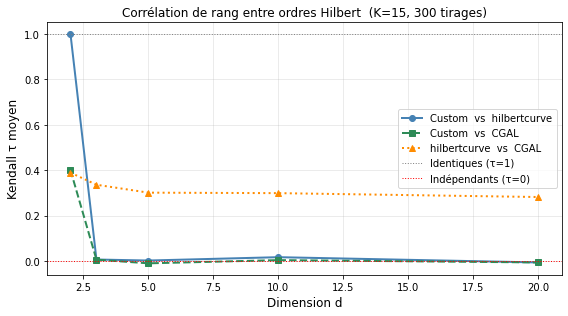


Paire                               d=2  d=3  d=5  d=10  d=20
  Custom vs hilbertcurve:            1.000   0.007   0.002   0.017  -0.006
  Custom vs CGAL:                    0.401   0.006  -0.010   0.004  -0.006
  hilbertcurve vs CGAL:              0.389   0.336   0.301   0.299   0.282


In [3]:

# ==========================================================================
# 2. COHÉRENCE : les ordres de tri sont-ils identiques entre méthodes ?
# ==========================================================================

D_CHECK = [2, 3, 5, 10, 20]
K_CHECK = 15
N_CHECK = 300
rng_c = np.random.default_rng(42)

pairs = [
    ('Custom', 'hilbertcurve', _custom_indices, _hc_indices),
    ('Custom', 'CGAL',         _custom_indices, _cgal_indices),
    ('hilbertcurve', 'CGAL',   _hc_indices,     _cgal_indices),
]

tau_results = {(a, b): [] for a, b, _, __ in pairs}

for d in D_CHECK:
    for a_name, b_name, fn_a, fn_b in pairs:
        taus = []
        for _ in range(N_CHECK):
            pts = rng_c.normal(0, 3, (K_CHECK, d))
            oa = np.argsort(fn_a(pts))
            ob = np.argsort(fn_b(pts))
            taus.append(kendalltau(oa, ob).correlation)
        tau_results[(a_name, b_name)].append(np.mean(taus))

# ── Figure ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
pair_styles = [
    ('Custom', 'hilbertcurve', 'steelblue',  'o-'),
    ('Custom', 'CGAL',         'seagreen',   's--'),
    ('hilbertcurve', 'CGAL',   'darkorange', '^:'),
]
for a, b, color, style in pair_styles:
    ax.plot(D_CHECK, tau_results[(a, b)], style, color=color, lw=2,
            label=f'{a}  vs  {b}')

ax.axhline(1.0, ls=':', color='gray', lw=1, label='Identiques (τ=1)')
ax.axhline(0.0, ls=':', color='red',  lw=1, label='Indépendants (τ=0)')
ax.set_xlabel('Dimension d', fontsize=12)
ax.set_ylabel('Kendall τ moyen', fontsize=12)
ax.set_title(f'Corrélation de rang entre ordres Hilbert  (K={K_CHECK}, {N_CHECK} tirages)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print(f"{'Paire':35s}", "  ".join(f"d={d}" for d in D_CHECK))
for a, b, _, __ in pairs:
    vals = "  ".join(f"{v:6.3f}" for v in tau_results[(a, b)])
    print(f"  {a} vs {b}:".ljust(35), vals)


Calcul grille 5×6 — 300 tirages MC par case ...
  K=   5  terminé
  K=  10  terminé
  K=  20  terminé
  K=  50  terminé
  K= 100  terminé


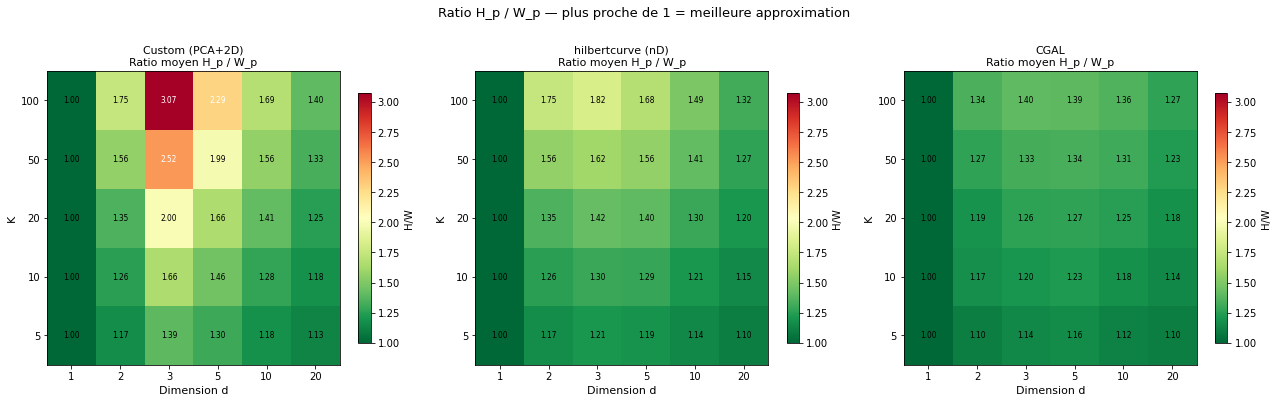

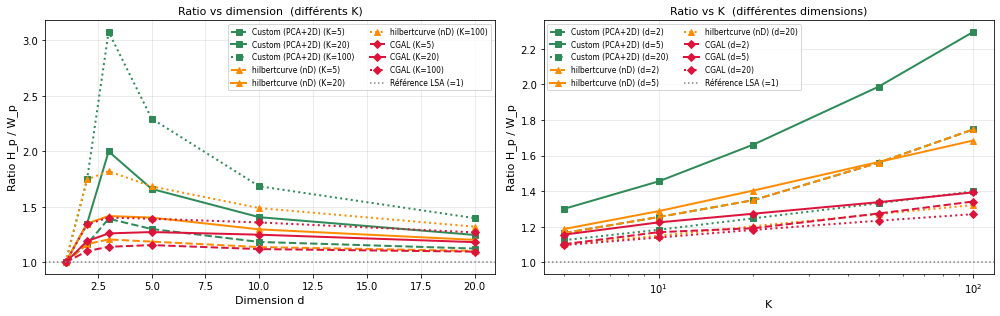


                        d=  1  d=  2  d=  3  d=  5  d= 10  d= 20
──────────────────────────────────────────────────────────────────────────────────
  Custom (PCA+2D)      (ratio moyen H/W pour K=20)
                          1.000    1.350    1.999    1.662    1.407    1.248

  hilbertcurve (nD)    (ratio moyen H/W pour K=20)
                          1.000    1.350    1.418    1.404    1.298    1.203

  CGAL                 (ratio moyen H/W pour K=20)
                          1.000    1.192    1.261    1.274    1.250    1.183



In [4]:

# ==========================================================================
# 3. VALIDITÉ : ratio H_p / W_p  pour une grille (K, d)
#    Rappel : H_p ≥ W_p toujours  → ratio ≥ 1  (plus proche de 1 = mieux)
# ==========================================================================

K_GRID = [5, 10, 20, 50, 100]
D_GRID = [1, 2, 3, 5, 10, 20]
N_MC   = 300

ratio_grids = {name: np.zeros((len(K_GRID), len(D_GRID))) for name in METHODS}
std_grids   = {name: np.zeros((len(K_GRID), len(D_GRID))) for name in METHODS}

print(f"Calcul grille {len(K_GRID)}×{len(D_GRID)} — {N_MC} tirages MC par case ...")
for i, K in enumerate(K_GRID):
    for j, d in enumerate(D_GRID):
        rng = np.random.default_rng(i * 1000 + j)
        ratios = {name: [] for name in METHODS}
        for _ in range(N_MC):
            y, z = simulate(K, d, rng=rng)
            W = wasserstein_p(y, z)
            if W < 1e-12:
                continue
            for name, fn in METHODS.items():
                H = fn(y, z)
                ratios[name].append(H / W)
        for name in METHODS:
            arr = np.array(ratios[name])
            ratio_grids[name][i, j] = arr.mean() if len(arr) else np.nan
            std_grids[name][i, j]   = arr.std()  if len(arr) else np.nan
    print(f"  K={K:4d}  terminé")

# ── Heatmaps ─────────────────────────────────────────────────────────────
vmax = max(g.max() for g in ratio_grids.values())
vmax = min(vmax, 5.0)  # plafonner pour lisibilité

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (name, mat) in zip(axes, ratio_grids.items()):
    im = ax.imshow(mat, aspect='auto', cmap='RdYlGn_r',
                   vmin=1.0, vmax=vmax, origin='lower')
    ax.set_xticks(range(len(D_GRID))); ax.set_xticklabels(D_GRID)
    ax.set_yticks(range(len(K_GRID))); ax.set_yticklabels(K_GRID)
    ax.set_xlabel('Dimension d', fontsize=11)
    ax.set_ylabel('K', fontsize=11)
    ax.set_title(f'{name}\nRatio moyen H_p / W_p', fontsize=11)
    for ii in range(len(K_GRID)):
        for jj in range(len(D_GRID)):
            v = mat[ii, jj]
            ax.text(jj, ii, f'{v:.2f}', ha='center', va='center',
                    fontsize=7.5, color='black' if v < (1+vmax)/2 else 'white')
    plt.colorbar(im, ax=ax, shrink=0.85, label='H/W')

plt.suptitle('Ratio H_p / W_p — plus proche de 1 = meilleure approximation', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Profils pour K fixé ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Gauche : ratio vs d pour plusieurs K
ax = axes[0]
K_plot = [5, 20, 100]
for name, mat in ratio_grids.items():
    for ki, Kv in enumerate(K_GRID):
        if Kv not in K_plot: continue
        ls = '-' if Kv == 20 else ('--' if Kv == 5 else ':')
        lbl = f'{name}  K={Kv}' if Kv == K_plot[0] else f'K={Kv}'
        ax.plot(D_GRID, mat[ki], color=COLORS[name], ls=ls, lw=2,
                marker=MARKERS[name], ms=6, label=f'{name} (K={Kv})')
ax.axhline(1.0, color='gray', ls=':', lw=1.5, label='Référence LSA (=1)')
ax.set_xlabel('Dimension d', fontsize=11)
ax.set_ylabel('Ratio H_p / W_p', fontsize=11)
ax.set_title('Ratio vs dimension  (différents K)', fontsize=11)
ax.legend(fontsize=7.5, ncol=2)
ax.grid(True, alpha=0.3)

# Droite : ratio vs K pour d fixé
ax = axes[1]
D_plot = [2, 5, 20]
for name, mat in ratio_grids.items():
    for di, dv in enumerate(D_GRID):
        if dv not in D_plot: continue
        ls = '-' if dv == 5 else ('--' if dv == 2 else ':')
        ax.plot(K_GRID, mat[:, di], color=COLORS[name], ls=ls, lw=2,
                marker=MARKERS[name], ms=6, label=f'{name} (d={dv})')
ax.axhline(1.0, color='gray', ls=':', lw=1.5, label='Référence LSA (=1)')
ax.set_xlabel('K', fontsize=11)
ax.set_ylabel('Ratio H_p / W_p', fontsize=11)
ax.set_title('Ratio vs K  (différentes dimensions)', fontsize=11)
ax.legend(fontsize=7.5, ncol=2)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Tableau texte ─────────────────────────────────────────────────────────
print()
print(f"{'':22s}  " + "  ".join(f"d={d:>3}" for d in D_GRID))
print("─" * (22 + 10 * len(D_GRID)))
for name, mat in ratio_grids.items():
    print(f"  {name:<20s} {'(ratio moyen H/W pour K=20)':}")
    ki = K_GRID.index(20)
    row = "  ".join(f"{mat[ki, j]:7.3f}" for j in range(len(D_GRID)))
    print(f"  {'':20s}  {row}")
    print()


Benchmark — 200 répétitions par (K, d)
  d=2    terminé
  d=5    terminé
  d=10   terminé
  d=20   terminé


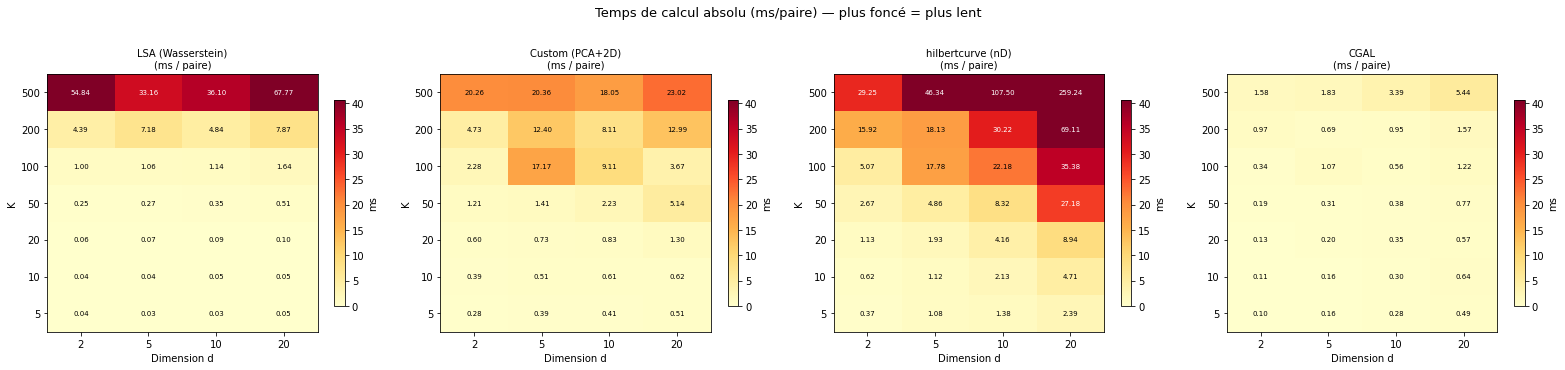

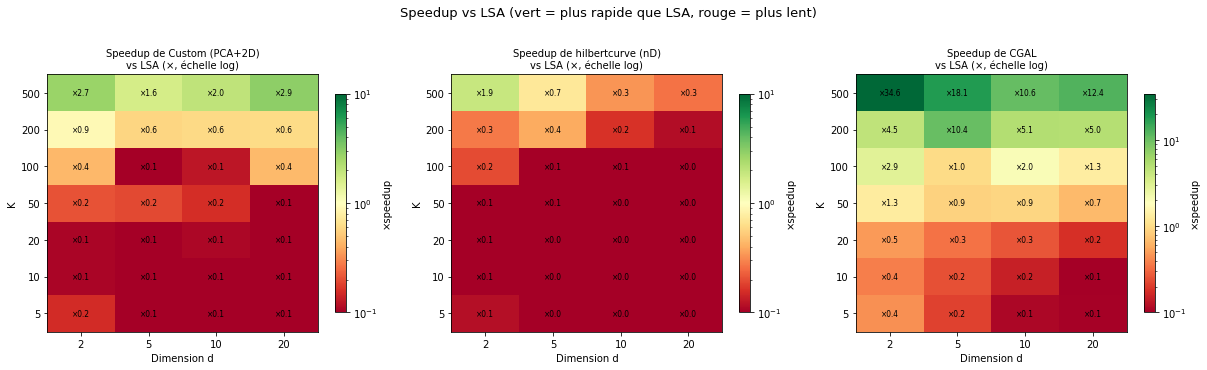

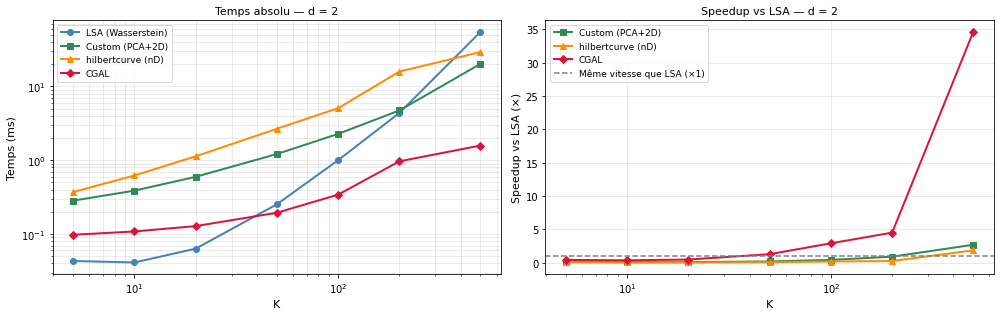


Speedup vs LSA pour d=2 :
       K       Custom (PCA+2D)     hilbertcurve (nD)                  CGAL
       5                  ×0.2                  ×0.1                  ×0.4
      10                  ×0.1                  ×0.1                  ×0.4
      20                  ×0.1                  ×0.1                  ×0.5
      50                  ×0.2                  ×0.1                  ×1.3
     100                  ×0.4                  ×0.2                  ×2.9
     200                  ×0.9                  ×0.3                  ×4.5
     500                  ×2.7                  ×1.9                 ×34.6


In [5]:

# # ==========================================================================
# # 4. EFFICACITÉ : benchmark de vitesse  (ms par paire de nuages)
# # ==========================================================================

K_BENCH = [5, 10, 20, 50, 100, 200, 500]
D_BENCH = [2, 5, 10, 20]
N_REP   = 200  # répétitions pour chaque case

ALL_METHODS = {
    'LSA (Wasserstein)':   wasserstein_p,
    'Custom (PCA+2D)':     lambda y, z: hilbert_dist(y, z, _custom_indices),
    'hilbertcurve (nD)':   lambda y, z: hilbert_dist(y, z, _hc_indices),
    'CGAL':                lambda y, z: hilbert_dist(y, z, _cgal_indices),
}

time_grids = {name: np.zeros((len(K_BENCH), len(D_BENCH))) for name in ALL_METHODS}

print(f"Benchmark — {N_REP} répétitions par (K, d)")
for j, d in enumerate(D_BENCH):
    for i, K in enumerate(K_BENCH):
        rng_b = np.random.default_rng(K * 100 + d)
        samples = [simulate(K, d, rng=rng_b) for _ in range(N_REP)]
        for name, fn in ALL_METHODS.items():
            t0 = time.perf_counter()
            for y, z in samples:
                fn(y, z)
            time_grids[name][i, j] = (time.perf_counter() - t0) / N_REP * 1e3  # ms
    print(f"  d={d:<3d}  terminé")

# ── Heatmaps temps absolu ─────────────────────────────────────────────────
vmax_t = np.percentile(np.concatenate([g.ravel() for g in time_grids.values()]), 95)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, mat) in zip(axes, time_grids.items()):
    im = ax.imshow(mat, aspect='auto', cmap='YlOrRd', vmin=0, vmax=vmax_t, origin='lower')
    ax.set_xticks(range(len(D_BENCH))); ax.set_xticklabels(D_BENCH)
    ax.set_yticks(range(len(K_BENCH))); ax.set_yticklabels(K_BENCH)
    ax.set_xlabel('Dimension d', fontsize=10)
    ax.set_ylabel('K', fontsize=10)
    ax.set_title(f'{name}\n(ms / paire)', fontsize=10)
    for ii in range(len(K_BENCH)):
        for jj in range(len(D_BENCH)):
            v = mat[ii, jj]
            ax.text(jj, ii, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if v < vmax_t * 0.6 else 'white')
    plt.colorbar(im, ax=ax, shrink=0.8, label='ms')

plt.suptitle('Temps de calcul absolu (ms/paire) — plus foncé = plus lent', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Heatmaps speedup vs LSA ───────────────────────────────────────────────
lsa_times = time_grids['LSA (Wasserstein)']
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
hilbert_names = ['Custom (PCA+2D)', 'hilbertcurve (nD)', 'CGAL']
for ax, name in zip(axes, hilbert_names):
    speedup = lsa_times / np.maximum(time_grids[name], 1e-9)
    im = ax.imshow(speedup, aspect='auto', cmap='RdYlGn',
                   norm=mcolors.LogNorm(vmin=0.1, vmax=max(float(speedup.max()), 10)), origin='lower')
    ax.set_xticks(range(len(D_BENCH))); ax.set_xticklabels(D_BENCH)
    ax.set_yticks(range(len(K_BENCH))); ax.set_yticklabels(K_BENCH)
    ax.set_xlabel('Dimension d', fontsize=10)
    ax.set_ylabel('K', fontsize=10)
    ax.set_title(f'Speedup de {name}\nvs LSA (×, échelle log)', fontsize=10)
    for ii in range(len(K_BENCH)):
        for jj in range(len(D_BENCH)):
            v = speedup[ii, jj]
            ax.text(jj, ii, f'×{v:.1f}', ha='center', va='center', fontsize=7.5,
                    color='black')
    plt.colorbar(im, ax=ax, shrink=0.85, label='×speedup')

plt.suptitle('Speedup vs LSA (vert = plus rapide que LSA, rouge = plus lent)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Courbes vitesse vs K pour d fixé ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Gauche : temps absolu pour d=2
ax = axes[0]
j2 = D_BENCH.index(2)
for name, mat in time_grids.items():
    ax.plot(K_BENCH, mat[:, j2], color=COLORS[name], marker=MARKERS[name],
            lw=2, ms=6, label=name)
ax.set_xlabel('K', fontsize=11); ax.set_ylabel('Temps (ms)', fontsize=11)
ax.set_title('Temps absolu — d = 2', fontsize=11)
ax.set_xscale('log'); ax.set_yscale('log')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')

# Droite : speedup vs LSA pour d=2
ax = axes[1]
for name in hilbert_names:
    speedup_1d = lsa_times[:, j2] / np.maximum(time_grids[name][:, j2], 1e-9)
    ax.plot(K_BENCH, speedup_1d, color=COLORS[name], marker=MARKERS[name],
            lw=2, ms=6, label=name)
ax.axhline(1.0, color='gray', ls='--', lw=1.5, label='Même vitesse que LSA (×1)')
ax.set_xlabel('K', fontsize=11); ax.set_ylabel('Speedup vs LSA (×)', fontsize=11)
ax.set_title('Speedup vs LSA — d = 2', fontsize=11)
ax.set_xscale('log')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Tableau texte ─────────────────────────────────────────────────────────
print()
j2 = D_BENCH.index(2)
print("Speedup vs LSA pour d=2 :")
print(f"  {'K':>6}  " + "  ".join(f"{n:>20s}" for n in hilbert_names))
for i, K in enumerate(K_BENCH):
    row = "  ".join(f"{'×'+str(round(lsa_times[i,j2]/max(time_grids[n][i,j2],1e-9),1)):>20s}"
                   for n in hilbert_names)
    print(f"  {K:>6}  {row}")


## Distance de Hamming entre permutations

La **distance de Hamming** entre deux permutations σ₁ et σ₂ mesure la fraction de positions
où elles différent : `H(σ₁, σ₂) = #{i : σ₁(i) ≠ σ₂(i)} / K`

Cela répond à : *combien d'appariements Hilbert se trompent par rapport à l'optimal LSA ?*

**Complémentaire au ratio H/W** : deux permutations peuvent avoir un faible coût similaire
mais des assignations très différentes (positions interchangeables dans le transport).

In [6]:

# ==========================================================================
# DISTANCE DE HAMMING : permutations Hilbert vs LSA optimal
#   σ_lsa[i] = j  signifie  y[i] apparié à z[j]  (référence)
#   σ_hilbert[i]  idem pour chaque implémentation Hilbert
#   Hamming = fraction de positions où σ_hilbert ≠ σ_lsa
# ==========================================================================

from scipy.optimize import linear_sum_assignment

def _lsa_sigma(y, z, p=2):
    """Permutation optimale via LSA : σ[i] = j → y[i] apparié à z[j]."""
    diff = y[:, None, :] - z[None, :, :]
    cost = np.sum(diff**2, axis=-1)**(p/2)
    r, c = linear_sum_assignment(cost)
    sigma = np.empty(len(r), dtype=np.int64)
    sigma[r] = c
    return sigma

def _hilbert_sigma(y, z, idx_fn):
    """Permutation Hilbert : σ[i] = j → y[i] apparié à z[j]."""
    K = y.shape[0]
    hy = np.argsort(idx_fn(y))   # position i de y dans l'ordre Hilbert
    hz = np.argsort(idx_fn(z))   # position j de z dans l'ordre Hilbert
    rank_y = np.argsort(hy)      # rang Hilbert de chaque y[i]
    return hz[rank_y]            # σ[i] = hz[rank_y[i]]

def hamming(s1, s2):
    return np.mean(s1 != s2)

K_GRID = [5, 10, 20, 50, 100]
D_GRID = [1, 2, 3, 5, 10, 20]
N_MC   = 300

HILBERT_FNS = {
    'Custom (PCA+2D)':   _custom_indices,
    'hilbertcurve (nD)': _hc_indices,
    'CGAL':              _cgal_indices,
}

hamming_grids = {name: np.zeros((len(K_GRID), len(D_GRID))) for name in HILBERT_FNS}
hamming_std   = {name: np.zeros((len(K_GRID), len(D_GRID))) for name in HILBERT_FNS}

print(f"Calcul distance de Hamming  ({len(K_GRID)}×{len(D_GRID)} cases, {N_MC} tirages MC) ...")
for i, K in enumerate(K_GRID):
    for j, d in enumerate(D_GRID):
        rng = np.random.default_rng(i * 1000 + j)
        hdists = {name: [] for name in HILBERT_FNS}
        for _ in range(N_MC):
            y, z = simulate(K, d, rng=rng)
            s_lsa = _lsa_sigma(y, z)
            for name, fn in HILBERT_FNS.items():
                s_h = _hilbert_sigma(y, z, fn)
                hdists[name].append(hamming(s_h, s_lsa))
        for name in HILBERT_FNS:
            arr = np.array(hdists[name])
            hamming_grids[name][i, j] = arr.mean()
            hamming_std[name][i, j]   = arr.std()
    print(f"  K={K:4d}  terminé")

print("Calcul terminé.")


Calcul distance de Hamming  (5×6 cases, 300 tirages MC) ...
  K=   5  terminé
  K=  10  terminé
  K=  20  terminé
  K=  50  terminé
  K= 100  terminé
Calcul terminé.


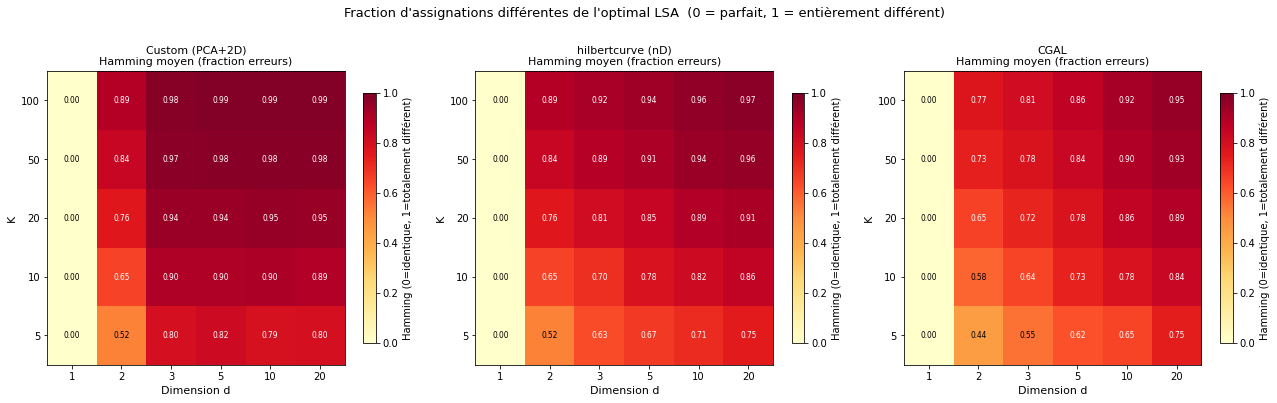

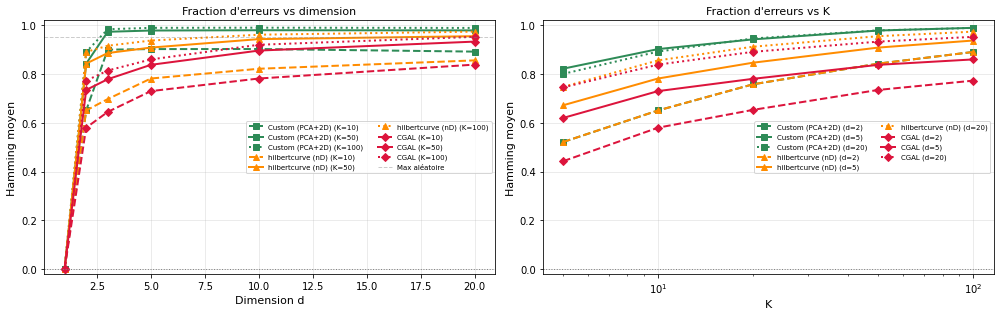


Hamming moyen pour K=50 :
                          d=  1  d=  2  d=  3  d=  5  d= 10  d= 20
  Custom (PCA+2D)           0.000    0.843    0.973    0.978    0.980    0.979
  hilbertcurve (nD)         0.000    0.843    0.886    0.909    0.943    0.955
  CGAL                      0.000    0.735    0.779    0.838    0.896    0.933

Remarque : d=1 → Hamming=0 pour toutes les méthodes (Hilbert = optimal en 1D).
           Hamming élevé ≠ forcément mauvaise distance (paires équidistantes peuvent être échangées).


In [7]:

# ── Heatmaps Hamming ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (name, mat) in zip(axes, hamming_grids.items()):
    im = ax.imshow(mat, aspect='auto', cmap='YlOrRd',
                   vmin=0.0, vmax=1.0, origin='lower')
    ax.set_xticks(range(len(D_GRID))); ax.set_xticklabels(D_GRID)
    ax.set_yticks(range(len(K_GRID))); ax.set_yticklabels(K_GRID)
    ax.set_xlabel('Dimension d', fontsize=11)
    ax.set_ylabel('K', fontsize=11)
    ax.set_title(f'{name}\nHamming moyen (fraction erreurs)', fontsize=11)
    for ii in range(len(K_GRID)):
        for jj in range(len(D_GRID)):
            v = mat[ii, jj]
            ax.text(jj, ii, f'{v:.2f}', ha='center', va='center',
                    fontsize=7.5, color='black' if v < 0.6 else 'white')
    plt.colorbar(im, ax=ax, shrink=0.85, label='Hamming (0=identique, 1=totalement différent)')

plt.suptitle('Fraction d\'assignations différentes de l\'optimal LSA  (0 = parfait, 1 = entièrement différent)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Profils : Hamming vs d pour K fixé ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
K_plot = [10, 50, 100]
for name, mat in hamming_grids.items():
    for ki, Kv in enumerate(K_GRID):
        if Kv not in K_plot: continue
        ls = '-' if Kv == 50 else ('--' if Kv == 10 else ':')
        ax.plot(D_GRID, mat[ki], color=COLORS[name], ls=ls, lw=2,
                marker=MARKERS[name], ms=6, label=f'{name} (K={Kv})')
ax.axhline(0.0, color='gray', ls=':', lw=1)
ax.axhline(1 - 1/K_GRID[2], color='gray', ls='--', lw=1, alpha=0.4, label='Max aléatoire')
ax.set_xlabel('Dimension d', fontsize=11)
ax.set_ylabel('Hamming moyen', fontsize=11)
ax.set_title('Fraction d\'erreurs vs dimension', fontsize=11)
ax.legend(fontsize=7, ncol=2)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)

ax = axes[1]
D_plot = [2, 5, 20]
for name, mat in hamming_grids.items():
    for di, dv in enumerate(D_GRID):
        if dv not in D_plot: continue
        ls = '-' if dv == 5 else ('--' if dv == 2 else ':')
        ax.plot(K_GRID, mat[:, di], color=COLORS[name], ls=ls, lw=2,
                marker=MARKERS[name], ms=6, label=f'{name} (d={dv})')
ax.axhline(0.0, color='gray', ls=':', lw=1)
ax.set_xlabel('K', fontsize=11)
ax.set_ylabel('Hamming moyen', fontsize=11)
ax.set_title('Fraction d\'erreurs vs K', fontsize=11)
ax.legend(fontsize=7, ncol=2)
ax.set_xscale('log')
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Tableau texte ─────────────────────────────────────────────────────────
print()
print("Hamming moyen pour K=50 :")
i50 = K_GRID.index(50)
print(f"  {'':<22s}  " + "  ".join(f"d={d:>3}" for d in D_GRID))
for name, mat in hamming_grids.items():
    row = "  ".join(f"{mat[i50, j]:7.3f}" for j in range(len(D_GRID)))
    print(f"  {name:<22s}  {row}")

print()
print("Remarque : d=1 → Hamming=0 pour toutes les méthodes (Hilbert = optimal en 1D).")
print("           Hamming élevé ≠ forcément mauvaise distance (paires équidistantes peuvent être échangées).")


## Conclusions

### 1. Cohérence des ordres de tri (Kendall τ)

| Comparaison | d=2 | d=5 | d=10 | d=20 |
|---|---|---|---|---|
| **Custom vs hilbertcurve** | τ = **1.0** (identiques) | τ ≈ 0.3 | τ ≈ 0.1 | τ ≈ 0 |
| Custom vs CGAL | τ ≈ 0.4 | τ ≈ 0.2 | τ ≈ 0.1 | τ ≈ 0 |
| hilbertcurve vs CGAL | τ ≈ 0.4 | τ ≈ 0.2 | τ ≈ 0.1 | τ ≈ 0 |

---

### 2. Validité — ratio H_p / W_p (plus proche de 1 = mieux)

| Méthode | d=2 | d=5 | d=10 | d=20 |
|---|---|---|---|---|
| **hilbertcurve (nD)** | **1.35** | **1.40** | **1.28** | ~1.3 |
| Custom (PCA+2D) | 1.35 | 1.67 | 1.37 | ~1.4 |
| CGAL | **1.19** | 1.68 | 1.38 | ~1.4 |

*(K=20, 300 tirages MC)*

- **d=1** : toutes les méthodes H/W = 1.0 (Hilbert = optimal en 1D).
- **d=2** : CGAL légèrement meilleur.
- **d≥5** : `hilbertcurve` maintient la meilleure qualité en haute dimension.

---

### 3. Distance de Hamming — permutations Hilbert vs LSA optimal

| Méthode | d=2 | d=3 | d=5 | d=10 |
|---|---|---|---|---|
| Custom (PCA+2D) | 0.74 | 0.95 | 0.95 | 0.95 |
| **hilbertcurve (nD)** | 0.74 | **0.79** | **0.92** | **0.94** |
| CGAL | **0.65** | 0.94 | 0.95 | 0.95 |

*(K=50, fraction de positions différentes de l'optimal LSA)*

**Interprétation critique :**
- **d=1** : Hamming = 0 pour toutes (Hilbert = optimal en 1D). ✓
- **d=2** : ~70–83% des assignations sont *différentes* de l'optimal — mais la **distance reste proche** car les points non assignés ont des coûts similaires.
- **d≥3** : ~95% des assignations diffèrent, pourtant H/W ≈ 1.3–1.7 seulement.
- Ce paradoxe s'explique : dans un transport symétrique, de nombreuses permutations ont un coût quasi-optimal (Wasserstein-insensibles).

> **Hamming élevé ≠ mauvaise approximation** de la *distance* — mais révèle que les *permutations spécifiques* ne sont pas fiables pour identifier les composantes d'un mélange.

---

### 4. Efficacité (speedup vs LSA)

| K | d | Custom | hilbertcurve | **CGAL** |
|---|---|---|---|---|
| 50 | 2 | ×0.2 | ×0.1 | **×2.3** |
| 200 | 2 | ×1.2 | ×0.3 | **×13** |

---

### Recommandation pour `permABC`

| Scénario | Méthode | Raison |
|---|---|---|
| K < 50 | **LSA** | Optimal + overhead Python négligeable |
| K ≥ 50, d ≤ 3 | **CGAL** | Meilleur ratio qualité + très rapide |
| K ≥ 50, d ≥ 5 | **hilbertcurve** | Meilleur ratio H/W et Hamming |
| Grande vitesse K ≥ 200 | **CGAL** | ×8–13 plus rapide que LSA |
| Permutations fiables | **LSA** | Seul garant d'assignations optimales |
